In [1]:
!pip install tensorflow
!pip install matplotlib
!pip install ipywidgets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 71.8 MB/s eta 0:00:00


In [6]:
# Import necessary libraries

from tensorflow.keras.applications.vgg16 import (
    VGG16,
    preprocess_input,
    decode_predictions
)

from tensorflow.keras.preprocessing.image import load_img, img_to_array

from IPython.display import display

import numpy as np
import matplotlib.pyplot as plt

from PIL import Image

import io
import ipywidgets as widgets

# Introduction
This lab is designed to introduce you to the basics of deep learning by interacting with a pre-built model. You'll understand the workflow of a deep learning project, including data preprocessing, model architecture, and making predictions. The goal is to familiarize yourself with the basics of deep learning without writing any code.


In [3]:
# Load the VGG16 model
model = VGG16(weights='imagenet')

# Display the model architecture
model.summary()


553467096/553467096 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step


Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc1 (Dense)                     │ (None, 4096)           │   102,764,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc2 (Dense)                     │ (None, 4096)           │    16,781,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ predictions (Dense)             │ (None, 1000)           │     4,097,000 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 138,357,544 (527.79 MB)

 Trainable params: 138,357,544 (527.79 MB)

 Non-trainable params: 0 (0.00 B)

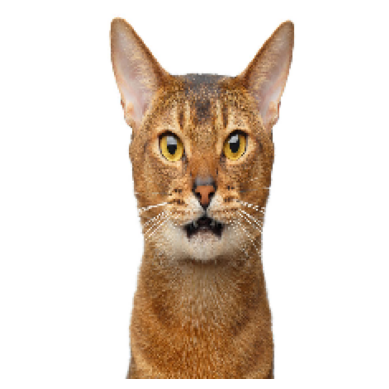

In [11]:
# Function to load and preprocess an image
def load_and_preprocess_image(image_path):

    # Load image and resize
    img = load_img(image_path, target_size=(224, 224))

    # Convert image to array
    img_array = img_to_array(img)

    # Expand dimensions for model input
    img_array = np.expand_dims(img_array, axis=0)

    # Apply VGG16 preprocessing
    img_array = preprocess_input(img_array)

    return img, img_array


# Replace 'sample.jpg' with your actual image filename
sample_image, processed_image = load_and_preprocess_image('cat.png')


# Display image
plt.imshow(sample_image)
plt.axis('off')
plt.show()


In [12]:
# Make predictions
predictions = model.predict(processed_image)

# Decode and print the predictions
decoded_predictions = decode_predictions(predictions, top=3)[0]
print(decoded_predictions)


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 931ms/step
35363/35363 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
[('n02124075', 'Egyptian_cat', np.float32(0.96438074)), ('n02127052', 'lynx', np.float32(0.013630435)), ('n02123045', 'tabby', np.float32(0.01135077))]


In [14]:
# Upload button to load images
upload = widgets.FileUpload()
display(upload)

# Button to make predictions
predict_button = widgets.Button(description="Make Prediction")
display(predict_button)

# Function to handle button click
def on_click(change):
    img_data = list(upload.value.values())[0]['content']
    img = Image.open(io.BytesIO(img_data))
    img = img.resize((224, 224))

    # Preprocess and predict
    img_array = img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array = preprocess_input(img_array)
    predictions = model.predict(img_array)
    decoded_predictions = decode_predictions(predictions, top=3)[0]

    # Display predictions
    print(decoded_predictions)

predict_button.on_click(on_click)


FileUpload(value={}, description='Upload')

Button(description='Make Prediction', style=ButtonStyle())

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 592ms/step
[('n02124075', 'Egyptian_cat', np.float32(0.9035218)), ('n02123045', 'tabby', np.float32(0.04989319)), ('n02127052', 'lynx', np.float32(0.02198551))]


# Conclusion and Discussion
Reflect on the lab activities. Discuss how the pre-trained model was able to make predictions, the role of data preprocessing, and the impact of input modifications on the model's predictions.


**This lab showed me how a pre-trained model like VGG16 can make predictions without needing to be trained from scratch. I learned that VGG16 was already trained on a huge dataset called ImageNet, so it has seen millions of images before. Because of that, it has learned to recognize common visual patterns like edges, shapes, textures, and object features. When I uploaded an image, the model broke it down into these patterns and compared them to what it already knew to make a prediction. I also saw how important data preprocessing is. The model only works properly if the image is resized to 224x224 and converted into the correct format. I had to make sure the image was also processed the same way the model was trained. Without these steps, the predictions would not be accurate because the model wouldn’t understand the input correctly. I noticed that changes to the input image can affect the results. Small changes like lighting or background don’t usually cause big problems, but larger changes like blurring, cropping, or distorting the image can lower accuracy. This is because the model depends on clear visual features to make its decision. Overall, I learned that pre-trained models are very powerful, but they still rely heavily on proper preprocessing and good-quality input images to work well.**